In [15]:
# ============================================================
# CELL 1: Imports and Load Data
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Evaluation
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

import joblib  # for saving models

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
RANDOM_SEED = 42

# Load customer features
customers = pd.read_csv(
    '../data/processed/customer_features.csv',
    dtype={'Customer ID': str}
)

print(f"Loaded: {customers.shape[0]:,} customers × {customers.shape[1]} features")
print(f"\nChurn distribution:")
print(customers['Churned'].value_counts())
print(f"\nChurn rate: {customers['Churned'].mean()*100:.1f}%")

Loaded: 5,878 customers × 18 features

Churn distribution:
Churned
1    2989
0    2889
Name: count, dtype: int64

Churn rate: 50.9%


In [7]:
# ============================================================
# CELL 2: Feature Preparation
# ============================================================
# We select features carefully — this is FEATURE SELECTION
#
# What we INCLUDE:
# - All RFM features (proven predictors)
# - Behavioral features (return rate, basket size etc.)
# - Cluster label (segment membership is predictive)
#
# What we EXCLUDE:
# - Customer ID (identifier, not a feature)
# - FirstPurchase / LastPurchase (raw dates — we already
#   captured this information in Recency and Tenure)
# - Churned (this is our target, not a feature)
#
# Interview answer on feature selection:
# "I excluded raw date columns because their information is
# already captured in engineered features like Recency and
# Tenure. Including raw dates would cause data leakage since
# the model could directly infer the churn label from them."

# Encode categorical features
# Country: Label encode (too many categories for one-hot)
# Persona: Label encode
le_country = LabelEncoder()
le_persona = LabelEncoder()

customers['Country_encoded'] = le_country.fit_transform(customers['Country'])
customers['Persona_encoded'] = le_persona.fit_transform(customers['Persona'])

# Define feature columns
FEATURE_COLS = [
    'Frequency', 'Monetary',
    'AvgOrderValue', 'AvgBasketSize', 'UniqueProducts',
    'Tenure', 'ReturnRate', 'ReturnCount',
    'PreferredDayOfWeek', 'PreferredMonth',
    'Country_encoded'
]

TARGET_COL = 'Churned'

X = customers[FEATURE_COLS]
y = customers[TARGET_COL]

# Train/test split — 80% train, 20% test
# Stratified: ensures same churn ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y  # critical for balanced splits
)

print(f"Training set:  {X_train.shape[0]:,} customers")
print(f"Test set:      {X_test.shape[0]:,} customers")
print(f"\nTrain churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate:  {y_test.mean()*100:.1f}%")
print(f"\nFeatures used: {len(FEATURE_COLS)}")
for f in FEATURE_COLS:
    print(f"  - {f}")

Training set:  4,702 customers
Test set:      1,176 customers

Train churn rate: 50.9%
Test churn rate:  50.9%

Features used: 11
  - Frequency
  - Monetary
  - AvgOrderValue
  - AvgBasketSize
  - UniqueProducts
  - Tenure
  - ReturnRate
  - ReturnCount
  - PreferredDayOfWeek
  - PreferredMonth
  - Country_encoded


In [11]:
# ============================================================
# CELL 3: Train and Compare 5 Models
# ============================================================
# We use cross-validation for honest model comparison
#
# Why cross-validation instead of a single train/test split?
# A single split can be lucky or unlucky depending on which
# customers end up in test. Cross-validation trains and tests
# on 5 different splits and averages results — much more
# reliable and what industry expects.
#
# Why Stratified K-Fold?
# Ensures each fold has the same churn ratio as the full
# dataset — important for balanced evaluation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Scale features — needed for Logistic Regression
# Tree-based models (RF, XGB, LGBM, CatBoost) don't need
# scaling but it doesn't hurt them either
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Define all models
# Why these specific hyperparameters?
# These are sensible defaults for a first run.
# We'll tune the best model in the next cell.
models = {
    'Logistic Regression': LogisticRegression(
        random_state=RANDOM_SEED,
        max_iter=1000,
        C=1.0             # regularization strength
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_SEED,
        n_jobs=-1         # use all CPU cores
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=RANDOM_SEED,
        eval_metric='logloss',
        verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100,
        random_state=RANDOM_SEED,
        verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
    iterations=100,
    random_state=RANDOM_SEED,
    verbose=0,
    thread_count=1    # fixes threading conflict with cross_validate
    )
}

# Run cross-validation for all models
cv_results = {}
print("Running 5-fold cross-validation...")
print("-" * 50)

for name, model in models.items():
    # Use scaled data for LR, raw for tree models
    X_cv = X_train_scaled if name == 'Logistic Regression' else X_train_scaled

    scores = cross_validate(
        model, X_cv, y_train,
        cv=cv,
        scoring=['accuracy', 'f1', 'roc_auc',
                 'precision', 'recall'],
        n_jobs=-1
    )

    cv_results[name] = {
        'Accuracy':  scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall':    scores['test_recall'].mean(),
        'F1':        scores['test_f1'].mean(),
        'ROC-AUC':   scores['test_roc_auc'].mean(),
    }
    print(f"✓ {name} done | ROC-AUC: {cv_results[name]['ROC-AUC']:.4f}")

print("\nAll models trained.")

Running 5-fold cross-validation...
--------------------------------------------------
✓ Logistic Regression done | ROC-AUC: 0.8324
✓ Random Forest done | ROC-AUC: 0.8809
✓ XGBoost done | ROC-AUC: 0.8872
✓ LightGBM done | ROC-AUC: 0.8928
✓ CatBoost done | ROC-AUC: 0.8934

All models trained.


MODEL COMPARISON — 5-FOLD CROSS-VALIDATION RESULTS
                     Accuracy  Precision  Recall      F1  ROC-AUC
CatBoost               0.7929     0.8010  0.7888  0.7948   0.8934
LightGBM               0.8001     0.8025  0.8055  0.8038   0.8928
XGBoost                0.7880     0.7945  0.7867  0.7905   0.8872
Random Forest          0.7824     0.7934  0.7742  0.7835   0.8809
Logistic Regression    0.7327     0.7155  0.7875  0.7497   0.8324

Best model by ROC-AUC: CatBoost
Best ROC-AUC score:    0.8934


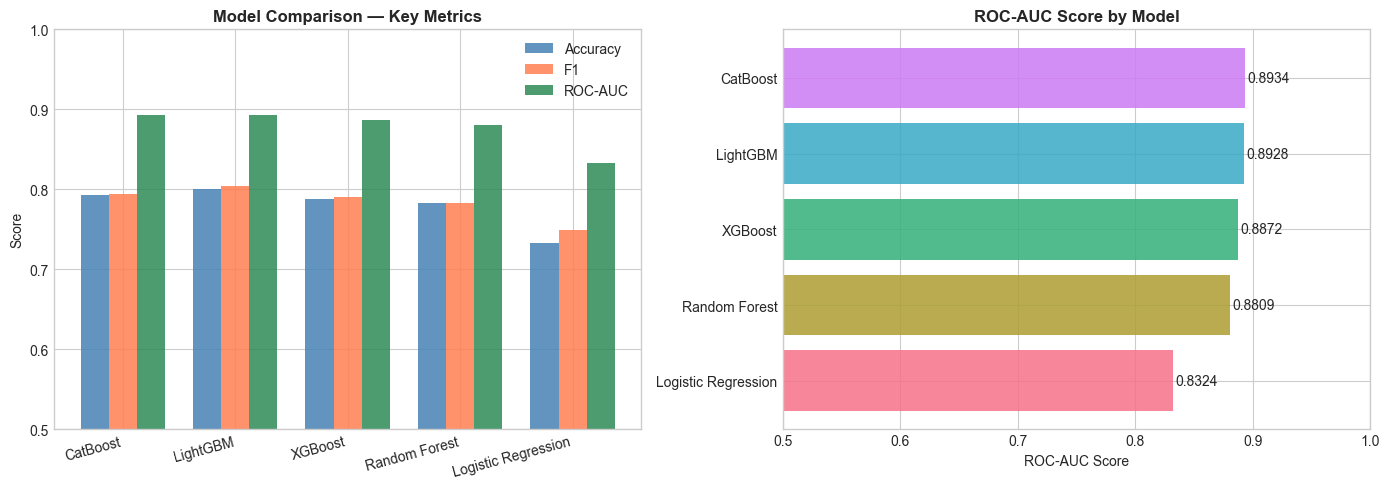

In [12]:
# ============================================================
# CELL 4: Model Comparison Table
# ============================================================
# This is the table that goes in your README and portfolio.
# It shows you evaluated multiple models — not just one.
# That's what professionals do.

results_df = pd.DataFrame(cv_results).T.round(4)
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("=" * 70)
print("MODEL COMPARISON — 5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)
print(f"\nBest model by ROC-AUC: {results_df['ROC-AUC'].idxmax()}")
print(f"Best ROC-AUC score:    {results_df['ROC-AUC'].max():.4f}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Accuracy', 'F1', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.25
colors = ['steelblue', 'coral', 'seagreen']

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, results_df[metric],
                width=width, label=metric, color=colors[i], alpha=0.85)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(results_df.index, rotation=15, ha='right')
axes[0].set_title('Model Comparison — Key Metrics',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.5, 1.0)
axes[0].legend()

# ROC-AUC bar chart (cleaner view)
colors_bar = sns.color_palette("husl", len(results_df))
axes[1].barh(results_df.index[::-1], results_df['ROC-AUC'][::-1],
             color=colors_bar, alpha=0.85)
axes[1].set_title('ROC-AUC Score by Model',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('ROC-AUC Score')
axes[1].set_xlim(0.5, 1.0)

for i, (idx, row) in enumerate(results_df[::-1].iterrows()):
    axes[1].text(row['ROC-AUC'] + 0.002, i,
                 f"{row['ROC-AUC']:.4f}", va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/12_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

BEST MODEL: CatBoost
TEST SET PERFORMANCE
  Accuracy     0.8010
  Precision    0.8182
  Recall       0.7826
  F1           0.8000
  ROC-AUC      0.9004
  PR-AUC       0.9090


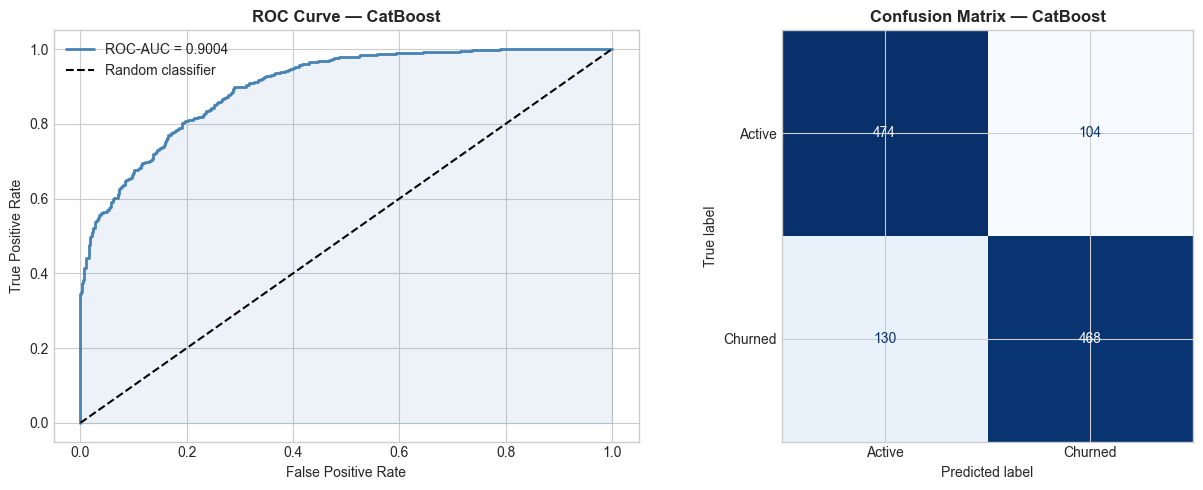

In [13]:
# ============================================================
# CELL 5: Final Model Evaluation on Held-Out Test Set
# ============================================================
# Cross-validation tells us training performance.
# Test set evaluation tells us REAL-WORLD performance.
# We only touch the test set ONCE — after model selection.
#
# Why only once? If we evaluate on the test set multiple
# times and keep adjusting, we're essentially training on
# it — defeating its purpose as an unbiased estimate.

BEST_MODEL_NAME = results_df['ROC-AUC'].idxmax()
best_model = models[BEST_MODEL_NAME]

# Train on full training set
best_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred       = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Calculate all metrics
test_metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1':        f1_score(y_test, y_pred),
    'ROC-AUC':   roc_auc_score(y_test, y_pred_proba),
    'PR-AUC':    average_precision_score(y_test, y_pred_proba)
}

print("=" * 50)
print(f"BEST MODEL: {BEST_MODEL_NAME}")
print("TEST SET PERFORMANCE")
print("=" * 50)
for metric, value in test_metrics.items():
    print(f"  {metric:<12} {value:.4f}")
print("=" * 50)

# Plot ROC curve + Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'ROC-AUC = {test_metrics["ROC-AUC"]:.4f}')
axes[0].plot([0,1], [0,1], 'k--', lw=1.5, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].set_title(f'ROC Curve — {BEST_MODEL_NAME}',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=10)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Active', 'Churned'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix — {BEST_MODEL_NAME}',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/13_roc_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ============================================================
# CELL 6: Save Model and Scaler
# ============================================================
# We save both the model AND the scaler together.
# Why save the scaler? When we deploy to Streamlit, new
# customer data must be scaled using the SAME scaler that
# was used during training. If we don't save it, predictions
# will be wrong.
#
# This is a very common production mistake beginners make.

os.makedirs('../models/saved', exist_ok=True)

# Save model
model_path = f'../models/saved/churn_model_{BEST_MODEL_NAME.lower().replace(" ", "_")}.pkl'
joblib.dump(best_model, model_path)

# Save scaler
scaler_path = '../models/saved/scaler.pkl'
joblib.dump(scaler, scaler_path)

# Save feature column names — needed for deployment
feature_path = '../models/saved/feature_cols.pkl'
joblib.dump(FEATURE_COLS, feature_path)

# Save label encoders
joblib.dump(le_country, '../models/saved/le_country.pkl')
joblib.dump(le_persona, '../models/saved/le_persona.pkl')

print(f"Model saved:    {model_path}")
print(f"Scaler saved:   {scaler_path}")
print(f"Features saved: {feature_path}")
print(f"\nModel type: {type(best_model).__name__}")
print(f"Features:   {len(FEATURE_COLS)}")
print(f"Test ROC-AUC: {test_metrics['ROC-AUC']:.4f}")

Model saved:    ../models/saved/churn_model_catboost.pkl
Scaler saved:   ../models/saved/scaler.pkl
Features saved: ../models/saved/feature_cols.pkl

Model type: CatBoostClassifier
Features:   11
Test ROC-AUC: 0.9004


In [16]:
# ============================================================
# FIX: Resave correct model and all required files
# ============================================================
import joblib
import os
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

os.makedirs('../models/saved', exist_ok=True)

customers = pd.read_csv(
    '../data/processed/customer_features.csv',
    dtype={'Customer ID': str}
)

le_country = LabelEncoder()
customers['Country_encoded'] = le_country.fit_transform(customers['Country'])

FEATURE_COLS = [
    'Frequency', 'Monetary',
    'AvgOrderValue', 'AvgBasketSize', 'UniqueProducts',
    'Tenure', 'ReturnRate', 'ReturnCount',
    'PreferredDayOfWeek', 'PreferredMonth',
    'Country_encoded'
]

X = customers[FEATURE_COLS]
y = customers['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train CatBoost
catboost_model = CatBoostClassifier(
    iterations=100, random_state=42,
    verbose=0, thread_count=1
)
catboost_model.fit(X_train_scaled, y_train)

# Save all required files
joblib.dump(catboost_model, '../models/saved/churn_model_catboost.pkl')
joblib.dump(scaler,         '../models/saved/scaler.pkl')
joblib.dump(FEATURE_COLS,   '../models/saved/feature_cols.pkl')
joblib.dump(le_country,     '../models/saved/le_country.pkl')

print("All model files saved:")
for f in os.listdir('../models/saved/'):
    print(f"  {f}")

All model files saved:
  churn_model_catboost.pkl
  churn_model_random_forest.pkl
  feature_cols.pkl
  le_country.pkl
  le_persona.pkl
  scaler.pkl
